In [15]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from pathlib import Path
import mcstasscript as ms
from scipy.optimize import curve_fit  

Pole cut: excluding |latitude| > 90.0 deg

--- Raw intensity ---
Total intensity inside pole cut      = 4.043953e-03
Beam-mask intensity                  = 4.035494e-03
Outside-beam intensity               = 8.458180e-06
Beam fraction of total               = 99.791 %

--- Cosine-corrected intensity ---
Total corrected intensity            = 4.049001e-03
Beam-mask corrected intensity        = 4.036879e-03
Outside-beam corrected intensity     = 1.212148e-05
Beam fraction of corrected total     = 99.701 %


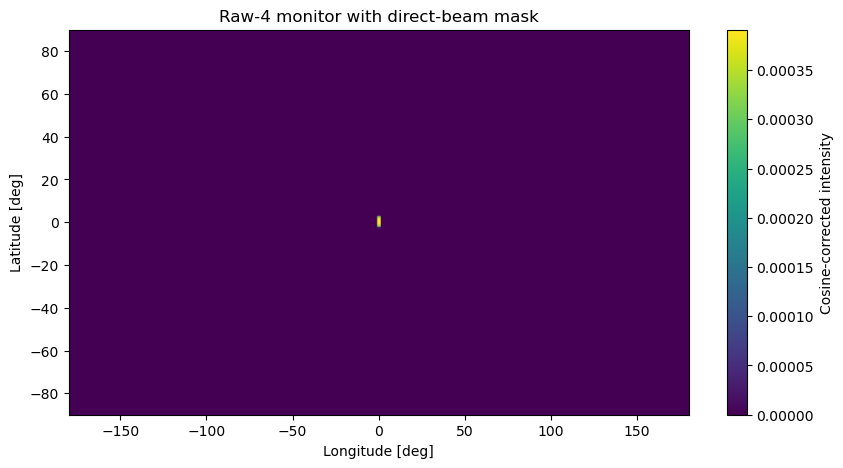

Clean intensity (exclude 0,2,4):      4.388180e-04
Recoverable useful part from raw 4:   8.458180e-06
Augmented cleaned intensity:          4.472762e-04
Recovered fraction relative to clean: 1.927%


In [16]:
# Load raw_4 monitor
raw4_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/geometry_optimization/offset_debug/offset_1mm")[5]
meta = raw4_mon.metadata
hits = raw4_mon.Intensity
hits_err = raw4_mon.Error

# H_clean        -> map excluding 0,2,4
H_clean_mon = ms.load_data("/Users/christian/Documents/Study/bachelor_project/geometry_optimization/offset_debug/offset_1mm")[11]
clean_meta = H_clean_mon.metadata
clean_hits = H_clean_mon.Intensity
clean_hits_err = H_clean_mon.Error

# H_raw4         -> raw-4 map
H_raw4 = hits.copy()


xmin, xmax, ymin, ymax = meta.limits
extent = [xmin, xmax, ymin, ymax]

Hmc = hits.copy()
Hmc_err = hits_err.copy()

# Geometry of PSD_monitor_4PI map
ny, nx = Hmc.shape
lon_centers = np.linspace(xmin + (xmax - xmin)/(2*nx), xmax - (xmax - xmin)/(2*nx), nx)
lat_centers = np.linspace(ymin + (ymax - ymin)/(2*ny), ymax - (ymax - ymin)/(2*ny), ny)

# Pole cut and cosine correction, same style as your previous analysis
pole_cut_deg = 0.0
cos_correction = np.cos(np.radians(lat_centers))[:, np.newaxis]
pole_mask = np.abs(lat_centers) <= (90.0 - pole_cut_deg)

print(f"Pole cut: excluding |latitude| > {90.0 - pole_cut_deg:.1f} deg")

Hmc_corrected = Hmc / cos_correction
Hmc_err_corrected = Hmc_err / cos_correction

Hmc_corrected = np.where(pole_mask[:, np.newaxis], Hmc_corrected, np.nan)
Hmc_err_corrected = np.where(pole_mask[:, np.newaxis], Hmc_err_corrected, np.nan)

# ------------------------------------------------------------
# Beam-mask settings
# ------------------------------------------------------------
# Adjust these if needed after looking at the plot
beam_lon_halfwidth_deg = 2.0
beam_lat_halfwidth_deg = 4.0

# Define direct-beam mask around (longitude, latitude) = (0, 0)
Lon, Lat = np.meshgrid(lon_centers, lat_centers)
beam_mask = (
    (np.abs(Lon) <= beam_lon_halfwidth_deg) &
    (np.abs(Lat) <= beam_lat_halfwidth_deg) &
    pole_mask[:, np.newaxis]
)

# Complement mask = everything outside the beam region but inside pole cut
scatter_mask = (~beam_mask) & pole_mask[:, np.newaxis]

# ------------------------------------------------------------
# Integrated intensities
# ------------------------------------------------------------
I_total_raw = np.nansum(Hmc[pole_mask, :])
I_beam_raw = np.nansum(Hmc[beam_mask])
I_outside_raw = np.nansum(Hmc[scatter_mask])

I_total_corr = np.nansum(Hmc_corrected)
I_beam_corr = np.nansum(Hmc_corrected[beam_mask])
I_outside_corr = np.nansum(Hmc_corrected[scatter_mask])

beam_frac_raw = I_beam_raw / I_total_raw if I_total_raw > 0 else np.nan
beam_frac_corr = I_beam_corr / I_total_corr if I_total_corr > 0 else np.nan

print("\n--- Raw intensity ---")
print(f"Total intensity inside pole cut      = {I_total_raw:.6e}")
print(f"Beam-mask intensity                  = {I_beam_raw:.6e}")
print(f"Outside-beam intensity               = {I_outside_raw:.6e}")
print(f"Beam fraction of total               = {100*beam_frac_raw:.3f} %")

print("\n--- Cosine-corrected intensity ---")
print(f"Total corrected intensity            = {I_total_corr:.6e}")
print(f"Beam-mask corrected intensity        = {I_beam_corr:.6e}")
print(f"Outside-beam corrected intensity     = {I_outside_corr:.6e}")
print(f"Beam fraction of corrected total     = {100*beam_frac_corr:.3f} %")

# ------------------------------------------------------------
# Plot for visual inspection
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    Hmc_corrected,
    extent=extent,
    origin="lower",
    aspect="auto"
)
ax.contour(
    Lon, Lat, beam_mask.astype(int),
    levels=[0.5],
    linewidths=1.5
)
ax.set_title("Raw-4 monitor with direct-beam mask")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
plt.colorbar(im, ax=ax, label="Cosine-corrected intensity")
plt.show()

import numpy as np

# Inputs assumed already loaded:
# H_clean        -> map excluding 0,2,4
# H_raw4         -> raw-4 map
# beam_mask      -> True inside direct-beam region
# pole_mask      -> True for kept latitudes

# Useful part of raw 4 = outside beam mask
raw4_useful = np.where((~beam_mask) & pole_mask[:, np.newaxis], H_raw4, 0.0)

I_clean = np.nansum(clean_hits[pole_mask, :])
I_raw4_useful = np.nansum(raw4_useful)
I_augmented = I_clean + I_raw4_useful

frac_recovered = I_raw4_useful / I_clean if I_clean > 0 else np.nan

print(f"Clean intensity (exclude 0,2,4):      {I_clean:.6e}")
print(f"Recoverable useful part from raw 4:   {I_raw4_useful:.6e}")
print(f"Augmented cleaned intensity:          {I_augmented:.6e}")
print(f"Recovered fraction relative to clean: {100*frac_recovered:.3f}%")

In [17]:
run_dir = "/Users/christian/Documents/Study/bachelor_project/geometry_optimization/offset_debug/offset_1mm"
mons = ms.load_data(run_dir)

idx = {
    "all": 0,
    "raw0": 1,
    "raw1": 2,
    "raw2": 3,
    "raw3": 4,
    "raw4": 5,
    "raw5": 6,
    "raw6": 7,
    "raw7": 8,
    "rawge8": 9,
    "with4": 10,
    "without4": 11,
}

pole_cut_deg = 5.0

def prepare_monitor(mon):
    meta = mon.metadata
    H = mon.Intensity.copy()
    Herr = mon.Error.copy()
    xmin, xmax, ymin, ymax = meta.limits
    extent = [xmin, xmax, ymin, ymax]

    ny, nx = H.shape
    lon = np.linspace(xmin, xmax, nx)
    lat = np.linspace(ymin, ymax, ny)

    cos_correction = np.cos(np.radians(lat))[:, np.newaxis]
    pole_mask = np.abs(lat) <= (90.0 - pole_cut_deg)

    Hcorr = H / cos_correction
    Herrcorr = Herr / cos_correction

    Hcorr = np.where(pole_mask[:, np.newaxis], Hcorr, np.nan)
    Herrcorr = np.where(pole_mask[:, np.newaxis], Herrcorr, np.nan)

    return {
        "H": H,
        "Herr": Herr,
        "Hcorr": Hcorr,
        "Herrcorr": Herrcorr,
        "extent": extent,
        "lon": lon,
        "lat": lat,
        "pole_mask": pole_mask,
        "meta": meta,
    }

data = {name: prepare_monitor(mons[i]) for name, i in idx.items()}

print(f"Loaded {len(data)} monitors")





Loaded 12 monitors


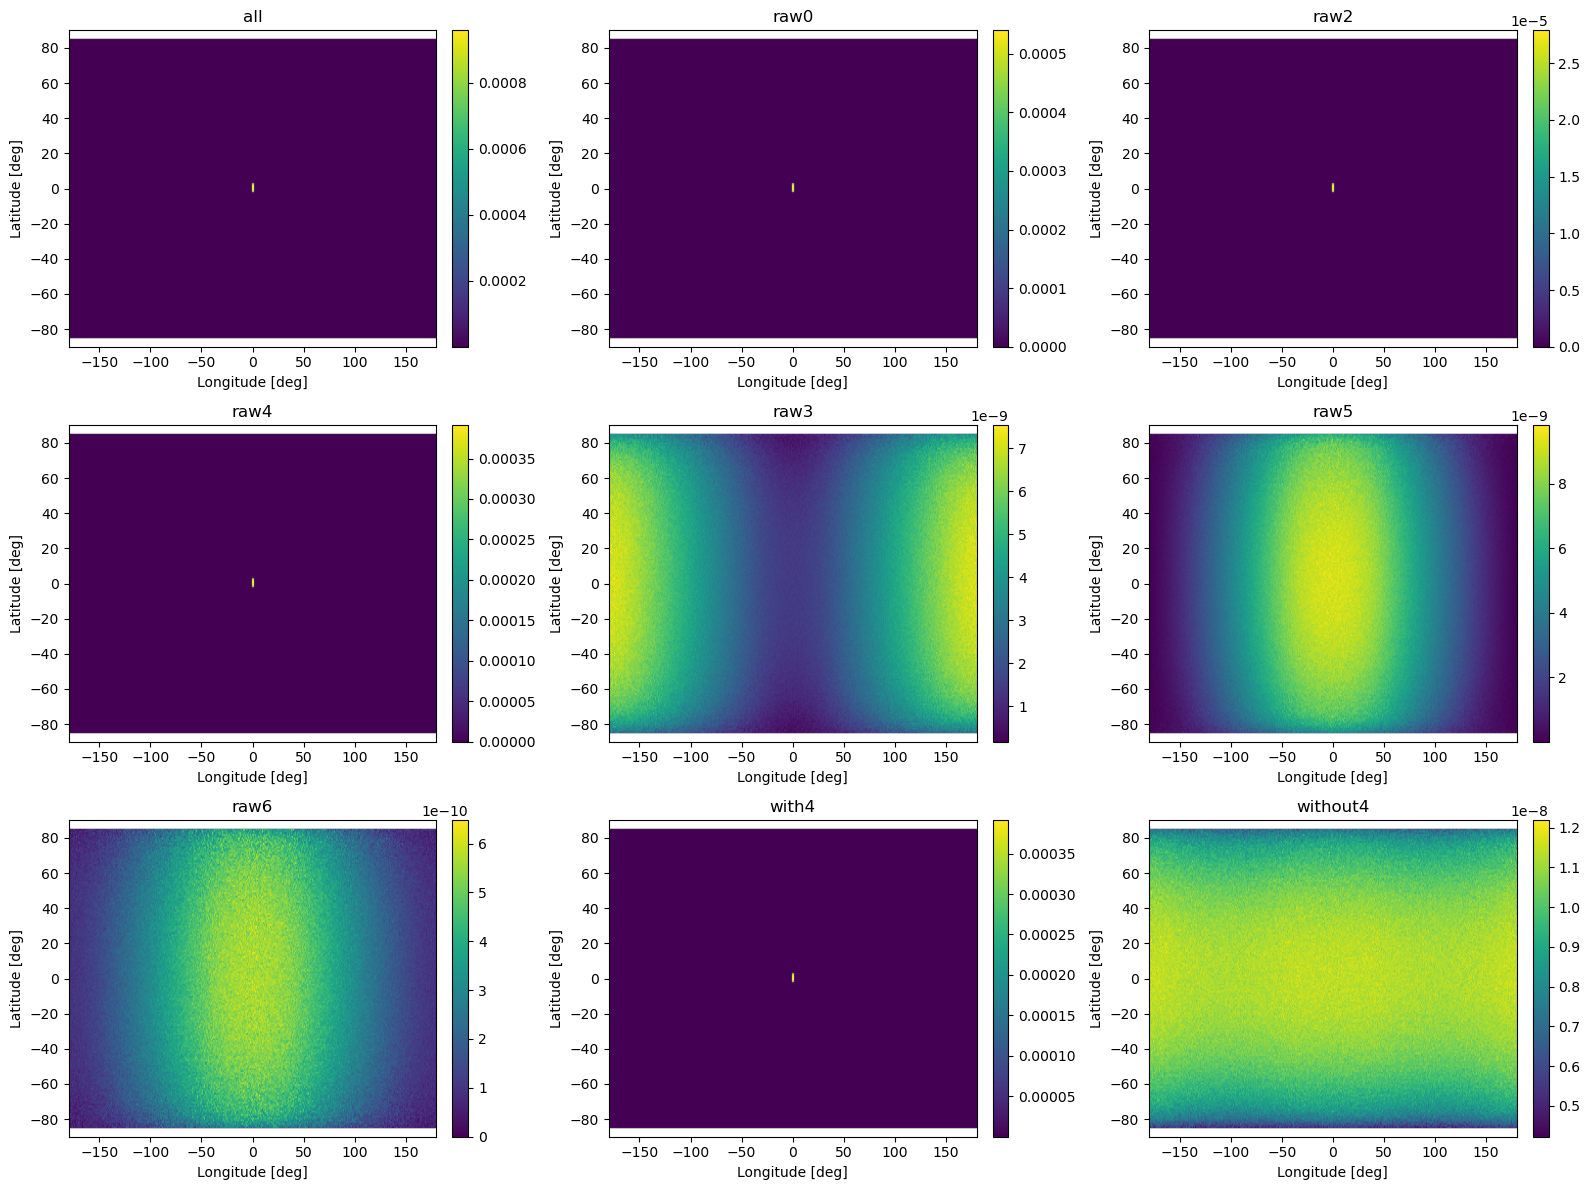

In [18]:
plot_names = ["all", "raw0", "raw2", "raw4", "raw3", "raw5", "raw6", "with4", "without4"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for ax, name in zip(axes, plot_names):
    d = data[name]
    im = ax.imshow(
        d["Hcorr"],
        extent=d["extent"],
        origin="lower",
        aspect="auto",
        cmap="viridis"
    )
    ax.set_title(name)
    ax.set_xlabel("Longitude [deg]")
    ax.set_ylabel("Latitude [deg]")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[len(plot_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

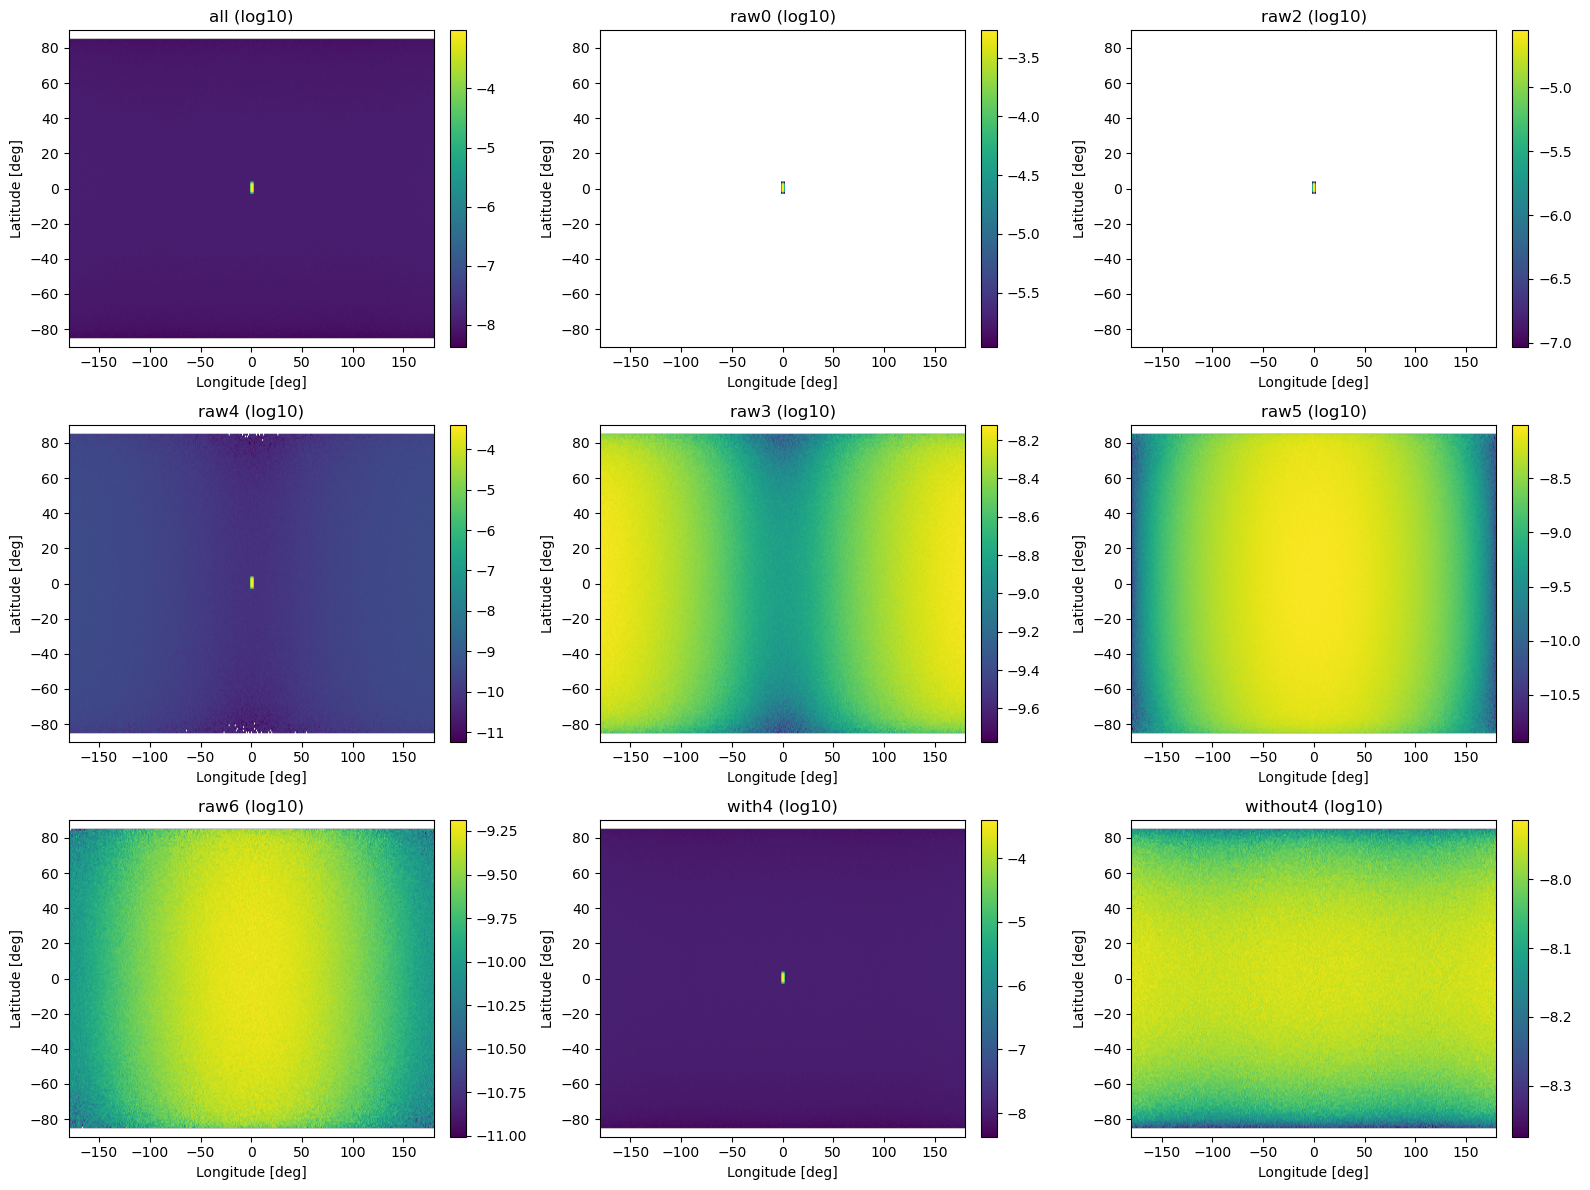

In [19]:
plot_names = ["all", "raw0", "raw2", "raw4", "raw3", "raw5", "raw6", "with4", "without4"]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for ax, name in zip(axes, plot_names):
    d = data[name]
    Hplot = np.array(d["Hcorr"], copy=True)
    Hplot[Hplot <= 0] = np.nan
    logH = np.log10(Hplot)

    im = ax.imshow(
        logH,
        extent=d["extent"],
        origin="lower",
        aspect="auto",
        cmap="viridis"
    )
    ax.set_title(f"{name} (log10)")
    ax.set_xlabel("Longitude [deg]")
    ax.set_ylabel("Latitude [deg]")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for ax in axes[len(plot_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

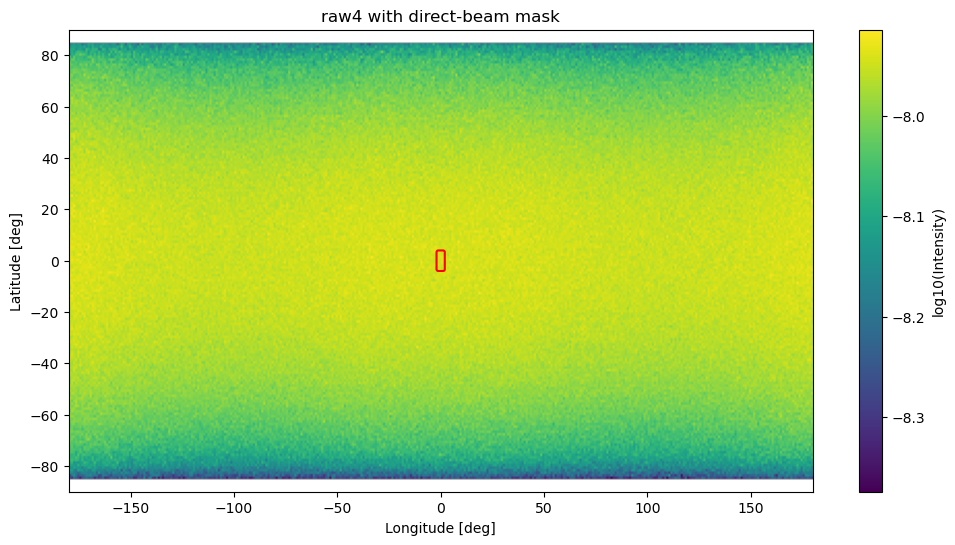

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(
    np.log10(Hplot),
    extent=d["extent"],
    origin="lower",
    aspect="auto",
    cmap="viridis"
)

ax.contour(
    Lon, Lat,
    beam_mask.astype(int),
    levels=[0.5],
    colors="red",
    linewidths=1.5
)

ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("raw4 with direct-beam mask")
fig.colorbar(im, ax=ax, label="log10(Intensity)")
plt.show()

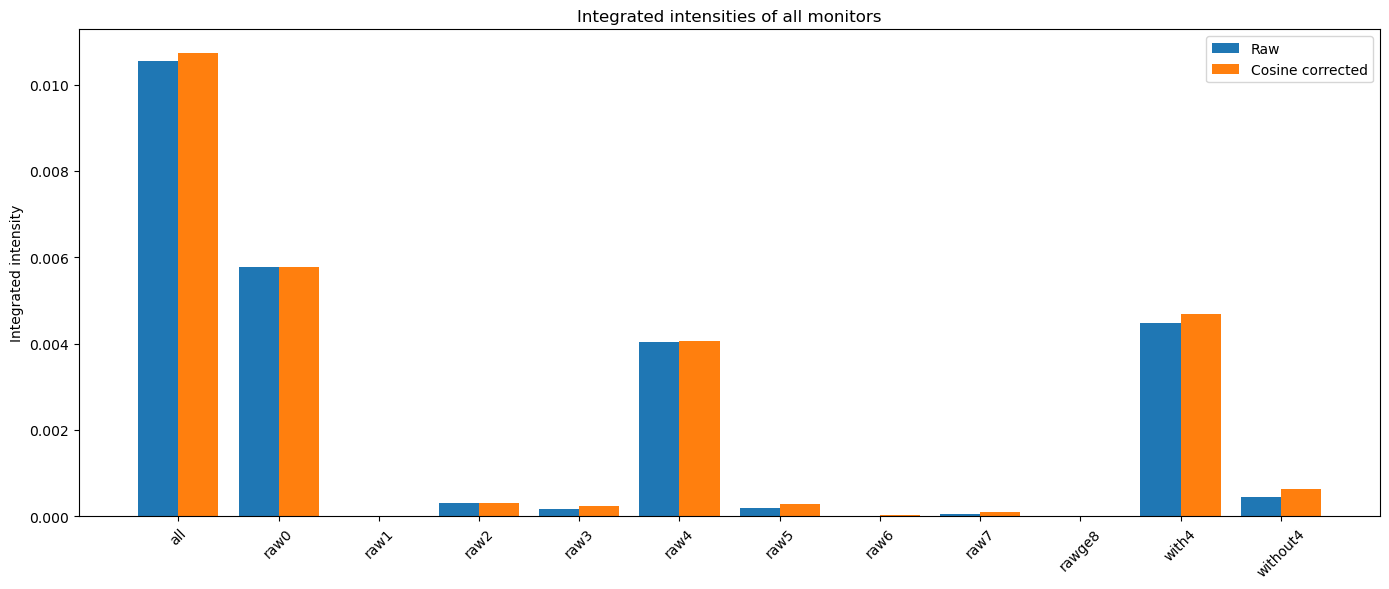

In [21]:
names_in_order = list(idx.keys())
I_raw = [np.nansum(data[name]["H"][data[name]["pole_mask"], :]) for name in names_in_order]
I_corr = [np.nansum(data[name]["Hcorr"]) for name in names_in_order]

x = np.arange(len(names_in_order))
width = 0.4

plt.figure(figsize=(14, 6))
plt.bar(x - width/2, I_raw, width, label="Raw")
plt.bar(x + width/2, I_corr, width, label="Cosine corrected")
plt.xticks(x, names_in_order, rotation=45)
plt.ylabel("Integrated intensity")
plt.title("Integrated intensities of all monitors")
plt.legend()
plt.tight_layout()
plt.show()

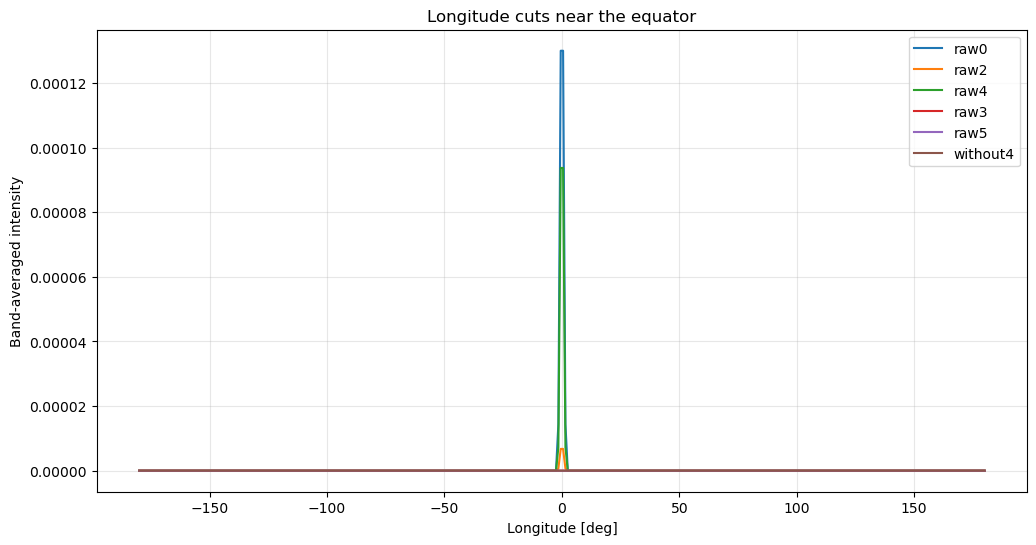

In [22]:
def longitude_cut(d, lat_halfwidth=10.0):
    lat = d["lat"]
    mask = np.abs(lat) <= lat_halfwidth
    cut = np.nanmean(d["Hcorr"][mask, :], axis=0)
    err = np.sqrt(np.nansum(d["Herrcorr"][mask, :]**2, axis=0)) / np.sum(mask)
    return d["lon"], cut, err

compare_names = ["raw0", "raw2", "raw4", "raw3", "raw5", "without4"]

plt.figure(figsize=(12, 6))
for name in compare_names:
    lon, cut, err = longitude_cut(data[name], lat_halfwidth=10.0)
    plt.plot(lon, cut, label=name)

plt.xlabel("Longitude [deg]")
plt.ylabel("Band-averaged intensity")
plt.title("Longitude cuts near the equator")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [23]:
d = data["raw4"]
lon = d["lon"]
lat = d["lat"]
Lon, Lat = np.meshgrid(lon, lat)

beam_mask = (
    (np.abs(Lon) <= beam_lon_halfwidth_deg) &
    (np.abs(Lat) <= beam_lat_halfwidth_deg)
)

valid_mask = d["pole_mask"][:, np.newaxis]
outside_mask = (~beam_mask) & valid_mask

I_total_raw = np.nansum(d["H"][d["pole_mask"], :])
I_beam_raw = np.nansum(d["H"][beam_mask & valid_mask])
I_out_raw = np.nansum(d["H"][outside_mask])

I_total_corr = np.nansum(d["Hcorr"])
I_beam_corr = np.nansum(d["Hcorr"][beam_mask & valid_mask])
I_out_corr = np.nansum(d["Hcorr"][outside_mask])

print("--- raw4 beam decomposition ---")
print(f"Raw total           = {I_total_raw:.6e}")
print(f"Raw beam            = {I_beam_raw:.6e}")
print(f"Raw outside beam    = {I_out_raw:.6e}")
print(f"Raw beam fraction   = {100*I_beam_raw/I_total_raw:.3f}%")

print()

print(f"Corrected total        = {I_total_corr:.6e}")
print(f"Corrected beam         = {I_beam_corr:.6e}")
print(f"Corrected outside beam = {I_out_corr:.6e}")
print(f"Corrected beam frac    = {100*I_beam_corr/I_total_corr:.3f}%")

--- raw4 beam decomposition ---
Raw total           = 4.043941e-03
Raw beam            = 4.035494e-03
Raw outside beam    = 8.446772e-06
Raw beam fraction   = 99.791%

Corrected total        = 4.048887e-03
Corrected beam         = 4.036895e-03
Corrected outside beam = 1.199237e-05
Corrected beam frac    = 99.704%


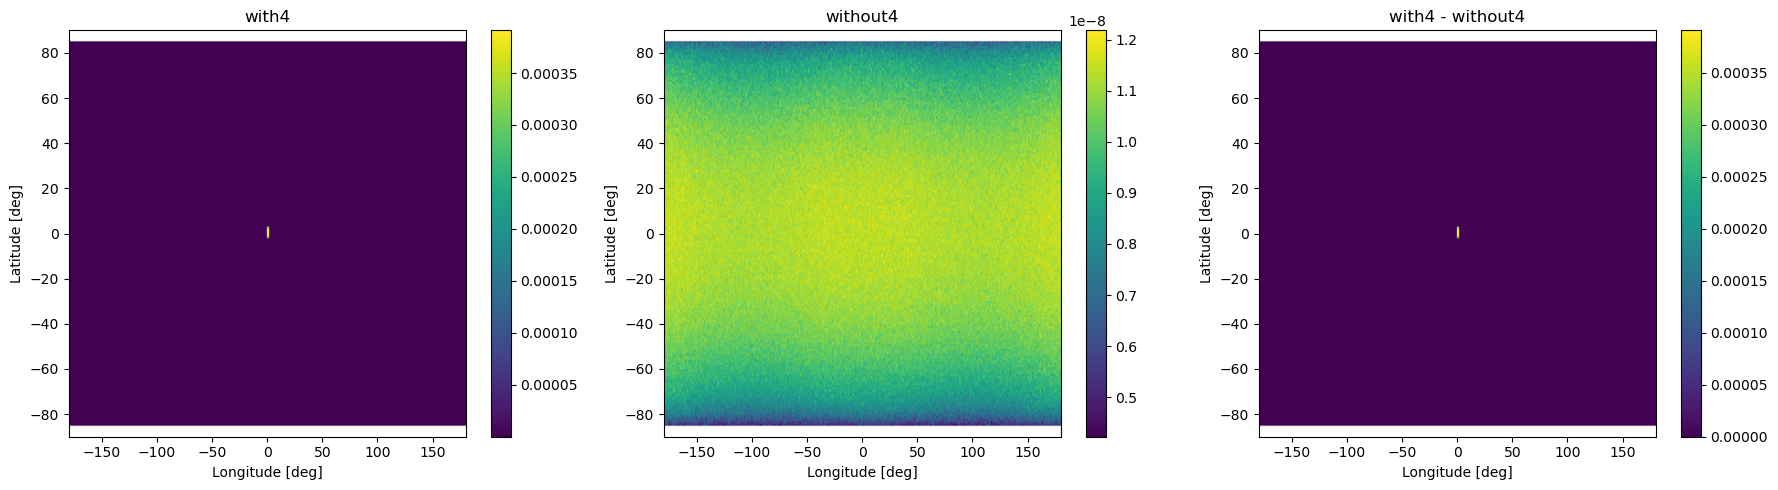

In [24]:
d_with = data["with4"]
d_without = data["without4"]

diff = d_with["Hcorr"] - d_without["Hcorr"]
rel = diff / d_without["Hcorr"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(d_with["Hcorr"], extent=d_with["extent"], origin="lower", aspect="auto", cmap="viridis")
axes[0].set_title("with4")
axes[0].set_xlabel("Longitude [deg]")
axes[0].set_ylabel("Latitude [deg]")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(d_without["Hcorr"], extent=d_without["extent"], origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("without4")
axes[1].set_xlabel("Longitude [deg]")
axes[1].set_ylabel("Latitude [deg]")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff, extent=d_with["extent"], origin="lower", aspect="auto", cmap="viridis")
axes[2].set_title("with4 - without4")
axes[2].set_xlabel("Longitude [deg]")
axes[2].set_ylabel("Latitude [deg]")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()